In [1]:
import os
from tqdm import tqdm

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import matplotlib.patches as patches

import tifffile as tiff
import cv2
import imageio.v2 as imageio

from skimage.morphology import skeletonize, opening, closing, disk
from scipy.ndimage import label, distance_transform_edt, binary_fill_holes
from skimage.morphology import remove_small_objects, skeletonize
from skimage.measure import find_contours, regionprops, regionprops_table, inertia_tensor, inertia_tensor_eigvals, label, perimeter
from skimage.segmentation import clear_border

from sklearn.linear_model import LinearRegression
from scipy.stats import linregress
from sklearn.metrics import r2_score

In [2]:
# helper functions

def add_brightest_z_to_dataframe(df, zstack_array):
    """
    Adds a column 'brightest_z' to the dataframe based on intensity at soma_x, soma_y across Z.
    
    Parameters:
    - df: pandas DataFrame with columns 'soma_x', 'soma_y'
    - zstack_array: numpy array of shape (z, height, width)
    
    Returns:
    - Modified DataFrame with 'brightest_z' column
    """
    brightest_z = []

    for idx, row in df.iterrows():
        x = int(row['soma_x'])
        y = int(row['soma_y'])

        if (0 <= y < zstack_array.shape[1]) and (0 <= x < zstack_array.shape[2]):
            # Extract intensity profile across Z at this x, y
            intensity_profile = zstack_array[:, y, x]
            brightest_slice = np.argmax(intensity_profile)
            brightest_z.append(brightest_slice)
        else:
            print(f"Warning: soma coords out of bounds for index {idx} — (x={x}, y={y})")
            brightest_z.append(np.nan)

    df = df.copy()
    df['brightest_z'] = brightest_z
    return df

def preprocess_and_segment(max_proj):
    # Normalize and CLAHE
    max_proj_norm = cv2.normalize(max_proj, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    clahe_img = clahe.apply(max_proj_norm)

    subtract = cv2.fastNlMeansDenoising(clahe_img)
    pre1 = cv2.adaptiveThreshold((255 - subtract), 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                  cv2.THRESH_BINARY, 101, 3)

    opened = opening(255 - pre1, disk(3))
    pre = closing(opened, disk(3))
    filled_image = binary_fill_holes(pre).astype(np.uint8)
    #filled_image = pre
    size_threshold = 1000
    labeled_array = label(filled_image)
    cleaned = remove_small_objects(labeled_array, min_size=size_threshold)
    labeled_array = label(cleaned)

    return labeled_array

def calculate_largest_region_fractal(labeled_array):
    regions = regionprops(labeled_array)
    if not regions:
        return np.nan
    # Pick the largest region
    largest = max(regions, key=lambda r: r.area)
    region_mask = labeled_array == largest.label
    return calculate_fractal_dimension(region_mask)

def calculate_largest_region_solidity(labeled_array):
    regions = regionprops(labeled_array)
    if not regions:
        return np.nan
    # Pick the largest region
    largest = max(regions, key=lambda r: r.area)
    region_mask = labeled_array == largest.label
    return calculate_solidity(region_mask)

def calculate_solidity(binary_image):
    labeled = label(binary_image)
    props = regionprops(labeled)

    if not props:
        return np.nan

    largest = max(props, key=lambda r: r.area)
    region_mask = labeled == largest.label

    area = largest.area
    convex_area = np.sum(convex_hull_image(region_mask))

    if convex_area == 0:
        return np.nan

    return area / convex_area

def generate_projection_df(df, zstack_array, micron_depth=10, z_step=1.67):
    slice_count = int(round(micron_depth / z_step))  # 6 or 13
    all_records = []

    for idx, row in df.iterrows():
        x0, x1 = int(row['bbox_xmin']), int(row['bbox_xmax'])
        y0, y1 = int(row['bbox_ymin']), int(row['bbox_ymax'])
        z_max = int(row['brightest_z'])
        label_id = row['label']
        crop_fractal = row.get('fractal_crop_maxproj', np.nan)

        cropped = zstack_array[:, y0:y1, x0:x1]
        z_start = max(0, z_max - slice_count + 1)
        z_end = min(zstack_array.shape[0], z_max + slice_count)

        for i in range(z_start, z_end - slice_count + 1):
            z_range = cropped[i:i + slice_count]  # shape: (slice_count, h, w)
            max_proj = np.max(z_range, axis=0)

            labeled = preprocess_and_segment(max_proj)
            fractal = calculate_largest_region_fractal(labeled)

            all_records.append({
                'label': label_id,
                'soma_x': row['soma_x'],
                'soma_y': row['soma_y'],
                'z_start': i,
                'z_end': i + slice_count,
                'fractal_dimension': fractal,
                'micron_depth': micron_depth,
                'fractal_crop_maxproj': crop_fractal
            })

    return pd.DataFrame(all_records)


def compute_cropped_maxproj_fractal(df, zstack_array, canvas_size=450):
    """
    For each row in df, crop the full z-stack using the bounding box,
    compute a full-depth max projection, and measure fractal dimension
    of the largest segmented object.
    
    Returns a copy of df with a new column: 'fractal_crop_maxproj'
    """
    fractals = []
    solidities = []
    max_proj = np.max(zstack_array, axis=0)
    labeled = preprocess_and_segment(max_proj)

    for idx, row in df.iterrows():
        
        x0, x1 = int(row['bbox_xmin']), int(row['bbox_xmax'])
        y0, y1 = int(row['bbox_ymin']), int(row['bbox_ymax'])

        # Crop z-stack over bounding box
        cropped = labeled[y0:y1, x0:x1]
        #plt.close()


         # Create centered canvas
        h, w = cropped.shape
        if h > canvas_size or w > canvas_size:
            fractals.append(np.nan)
            continue

        canvas = np.zeros((canvas_size, canvas_size), dtype=cropped.dtype)
        y_offset = (canvas_size - h) // 2
        x_offset = (canvas_size - w) // 2
        canvas[y_offset:y_offset + h, x_offset:x_offset + w] = cropped


        # Compute fractal on centered mask
        fractal = calculate_largest_region_fractal(canvas)
        fractals.append(fractal)

    df = df.copy()
    df['fractal_crop_maxproj'] = fractals
    return df

def find_soma_by_distance_transform(binary_image):
    distance_transform = distance_transform_edt(binary_image)
    skeleton = skeletonize(binary_image)
    skeleton_coords = np.column_stack(np.where(skeleton))
    max_distance_point = skeleton_coords[np.argmax(distance_transform[skeleton])]
    return max_distance_point, distance_transform, skeleton

def segment_soma(binary_image, soma_coords, distance_transform, threshold_ratio=0.5):
    threshold_value = distance_transform[soma_coords[0], soma_coords[1]] * threshold_ratio
    soma_segment = distance_transform >= threshold_value
    labeled_soma = label(soma_segment)
    soma_label = labeled_soma[soma_coords[0], soma_coords[1]]
    soma_region = labeled_soma == soma_label
    return soma_region

def compute_circularity(region_mask):
    area = np.sum(region_mask)
    perim = perimeter(region_mask)
    if perim == 0:
        return 0
    circularity = 4 * np.pi * area / (perim ** 2)
    return circularity

def is_soma_like(region_mask, circularity_threshold=0.5, area_threshold=100):
    circ = compute_circularity(region_mask)
    area = np.sum(region_mask)
    return circ > circularity_threshold and area > area_threshold

def filter_regions_with_soma(binary_mask, circularity_threshold=0.5, area_threshold=100, debug=False):
    # make sure the cells have a soma
    labeled_mask = label(binary_mask)
    output_mask = np.zeros_like(binary_mask)
    soma_coords_list = []

    for region in regionprops(labeled_mask):
        region_mask = labeled_mask == region.label

        try:
            soma_coords, dist_transform, _ = find_soma_by_distance_transform(region_mask)
            soma_seg = segment_soma(region_mask, soma_coords, dist_transform)

            if is_soma_like(soma_seg, circularity_threshold, area_threshold):
                output_mask[region_mask] = region.label
                soma_coords_list.append(soma_coords)
        except Exception as e:
            print(f"Skipping region {region.label} due to error: {e}")

    if debug:
        # Plotting the filtered mask with soma centers
        plt.figure(figsize=(8, 8))
        plt.imshow(output_mask, cmap='nipy_spectral')
        for (y, x) in soma_coords_list:
            plt.plot(x, y, 'ro', markersize=5)  # x, y order
        plt.title("Filtered Regions with Soma Centers")
        plt.axis('off')
        plt.show()

    return output_mask

def calculate_fractal_dimension(binary_image):
    def boxcount(Z, k):
        S = np.add.reduceat(
            np.add.reduceat(Z, np.arange(0, Z.shape[0], k), axis=0),
            np.arange(0, Z.shape[1], k), axis=1)
        return len(np.where((S > 0) & (S < k*k))[0])

    Z = binary_image > 0
    p = min(Z.shape)
    n = 2**np.floor(np.log2(p))
    n = int(np.log2(n))
    sizes = 2**np.arange(n, 1, -1)

    counts = []
    for size in sizes:
        counts.append(boxcount(Z, size))

    coeffs = np.polyfit(np.log(sizes), np.log(counts), 1)
    return -coeffs[0]

def extract_soma_and_fractal_data(filtered_mask):
    labeled_mask = label(filtered_mask)
    records = []

    for region in regionprops(labeled_mask):
        region_mask = labeled_mask == region.label

        try:
            soma_coords, dist_transform, _ = find_soma_by_distance_transform(region_mask)
            soma_seg = segment_soma(region_mask, soma_coords, dist_transform)
            fractal_dim = calculate_fractal_dimension(region_mask)

            # Get bounding box
            bbox = region.bbox  # (min_row, min_col, max_row, max_col)

            records.append({
                'label': region.label,
                'soma_y': soma_coords[0],
                'soma_x': soma_coords[1],
                'fractal_dimension': fractal_dim,
                'bbox_ymin': bbox[0],
                'bbox_xmin': bbox[1],
                'bbox_ymax': bbox[2],
                'bbox_xmax': bbox[3]
            })

        except Exception as e:
            print(f"Error in region {region.label}: {e}")
            continue

    return pd.DataFrame(records)

def _add_scalebar(ax, shape, pixel_size, scalebar_um=50):
    scale_bar_px = int(round(scalebar_um * pixel_size))
    height, width = shape
    x_bar_start = width - scale_bar_px - 10
    y_bar_start = height - 20

    bar = patches.Rectangle((x_bar_start, y_bar_start), scale_bar_px, 5,
                            linewidth=0, edgecolor='none', facecolor='red')
    ax.add_patch(bar)
    ax.text(x_bar_start + scale_bar_px / 2, y_bar_start - 10,
            f"{scalebar_um} µm", color='red', ha='center', va='bottom', fontsize=10)
    
    
# testing this version:
def generate_projection_df(df, zstack_array, micron_depth=10, z_step=1.67):
    slice_count = int(round(micron_depth / z_step))  # e.g. 6 or 13 slices
    all_records = []

    for idx, row in df.iterrows():
        x0, x1 = int(row['bbox_xmin']), int(row['bbox_xmax'])
        y0, y1 = int(row['bbox_ymin']), int(row['bbox_ymax'])
        z_max = int(row['brightest_z'])
        label_id = row['label']
        crop_fractal = row.get('fractal_crop_maxproj', np.nan)

        z_start = max(0, z_max - slice_count + 1)
        z_end = min(zstack_array.shape[0], z_max + slice_count)

        for i in range(z_start, z_end - slice_count + 1):
            z_range = zstack_array[i:i + slice_count]  # shape: (slice_count, H, W)
            max_proj = np.max(z_range, axis=0)         # full-image max projection

            # Segment the entire max projection
            labeled = preprocess_and_segment(max_proj)

            # Zero out everything outside bounding box
            #mask_bounded = np.zeros_like(labeled)
            #mask_bounded[y0:y1, x0:x1] = labeled[y0:y1, x0:x1]
            bbox_region = labeled[y0:y1, x0:x1]
            
            # 1000 (old window) divided by vizgen pixel to micron divided by ours
            canvas_size = 450
            h, w = bbox_region.shape
            
            if h > canvas_size or w > canvas_size:
                continue
            
            canvas = np.zeros((canvas_size, canvas_size), dtype=labeled.dtype)

            # Center coordinates
            y_offset = (canvas_size - h) // 2
            x_offset = (canvas_size - w) // 2

            # Paste into canvas
            canvas[y_offset:y_offset + h, x_offset:x_offset + w] = bbox_region

            # Now measure largest region in the restricted field
            fractal = calculate_largest_region_fractal(canvas)

            all_records.append({
            'label': label_id,
            'soma_x': row['soma_x'],
            'soma_y': row['soma_y'],
            'z_start': i,
            'z_end': i + slice_count,
            'fractal_dimension': fractal,
            'micron_depth': micron_depth,
            'fractal_crop_maxproj': crop_fractal
            })

    return pd.DataFrame(all_records)

In [3]:
# analysis and plotting

def analyze_all_488_images(root_dir, circularity_threshold=0.1, area_threshold=275):
    df_all_10micron = []
    df_all_15micron = []
    df_all_20micron = []

    # Collect all matching file paths first
    tif_paths = []
    for root, _, files in os.walk(root_dir):
        for fname in files:
            if fname.endswith(".tif") and "488" in fname:
                tif_paths.append(os.path.join(root, fname))

    for path in tqdm(tif_paths, desc="Processing 488 images"):
        fname = os.path.basename(path)

        try:
            z_stack = tiff.imread(path)
            max_proj = np.max(z_stack, axis=0)

            cleaned = preprocess_and_segment(max_proj)
            filtered = filter_regions_with_soma(cleaned,
                                                circularity_threshold=circularity_threshold,
                                                area_threshold=area_threshold,
                                                debug=False)

            df = extract_soma_and_fractal_data(filtered)
            if df.empty:
                continue

            df_with_z = add_brightest_z_to_dataframe(df, z_stack)
            df_with_crop = compute_cropped_maxproj_fractal(df_with_z, z_stack)
            df_with_crop['fname'] = fname
            df_with_crop['id'] = df_with_crop['label'].astype(str) + "_" + fname
            
            df_10 = generate_projection_df(df_with_crop, z_stack, micron_depth=10)
            df_15 = generate_projection_df(df_with_crop, z_stack, micron_depth=15)
            df_20 = generate_projection_df(df_with_crop, z_stack, micron_depth=20)

            df_10['fname'] = fname
            df_10['id'] = df_10['label'].astype(str) + "_" + fname
            
            df_15['fname'] = fname
            df_15['id'] = df_15['label'].astype(str) + "_" + fname

            df_20['fname'] = fname
            df_20['id'] = df_20['label'].astype(str) + "_" + fname
            
            df_all_10micron.append(df_10)
            df_all_15micron.append(df_15)
            df_all_20micron.append(df_20)

        except Exception as e:
            print(f"Error processing {fname}: {e}")
            continue

    final_df_10 = pd.concat(df_all_10micron, ignore_index=True)
    final_df_15 = pd.concat(df_all_15micron, ignore_index=True)
    final_df_20 = pd.concat(df_all_20micron, ignore_index=True)

    return final_df_10, final_df_15, final_df_20


def plot_image_and_scatter_grid_2x3(max_proj, filtered_mask, df_list, micron_depths, pixel_size=4.158, save_pdf=None):
    """
    2x3 figure:
    - [0,0]: raw image
    - [1,0]: filtered mask
    - [0,1], [0,2], [1,1]: scatter plots (10, 15, 20 µm)
    - [1,2]: slope ± 95% CI bar plot
    """
    assert len(df_list) == 3 and len(micron_depths) == 3, "Expect 3 dataframes and depths"

    fig, axs = plt.subplots(2, 3, figsize=(18, 10))
    slope_vals, ci_vals = [], []

    # --- Raw Max Projection ---
    axs[0, 0].imshow(max_proj, cmap='gray')
    axs[0, 0].set_title("Max Projection (Raw)")
    axs[0, 0].axis('off')
    _add_scalebar(axs[0, 0], max_proj.shape, pixel_size)

    # --- Filtered Mask ---
    axs[1, 0].imshow(filtered_mask, cmap='nipy_spectral')
    axs[1, 0].set_title("Filtered Regions")
    axs[1, 0].axis('off')
    _add_scalebar(axs[1, 0], max_proj.shape, pixel_size)

    # --- Scatter Plots ---
    scatter_positions = [(0, 1), (0, 2), (1, 1)]
    for (row, col), df, depth in zip(scatter_positions, df_list, micron_depths):
        ax = axs[row, col]

        grouped = df.groupby('id').agg({
            'fractal_dimension': 'mean',
            'fractal_crop_maxproj': 'mean'
        }).dropna()

        x = grouped['fractal_crop_maxproj'].values
        y = grouped['fractal_dimension'].values

        slope, intercept, r_value, _, std_err = linregress(x, y)
        y_pred = slope * x + intercept
        
        # use the z-critical value for an approximation of the
        # confidence interval. Large enough sample size for this
        # to work.
        ci = 1.96 * std_err

        slope_vals.append(slope)
        ci_vals.append(ci)

        sns.scatterplot(x=x, y=y, ax=ax, alpha=0.7)
        ax.plot(x, y_pred, 'r--', label=f"Slope = {slope:.2f}\nR² = {r_value**2:.2f}")
        ax.set_title(f"{depth} µm Projection")
        ax.set_xlabel("Full Max Projection Fractal")
        ax.set_ylabel("Mean Projection Fractal")
        ax.grid(True)
        ax.legend()

    # --- Bar Plot: Slope ± CI ---
    ax_bar = axs[1, 2]
    x_labels = [f"{d}µm" for d in micron_depths]
    x_pos = np.arange(len(slope_vals))

    bars = ax_bar.bar(x_pos, slope_vals, color='skyblue')
    ax_bar.errorbar(x_pos, slope_vals, yerr=ci_vals, fmt='none', ecolor='black', capsize=5)
    ax_bar.set_xticks(x_pos)
    ax_bar.set_xticklabels(x_labels)
    ax_bar.set_title("Slope ± 95% CI")
    ax_bar.set_ylabel("Slope")
    ax_bar.set_xlabel("Projection Depth")
    ax_bar.grid(True)

    plt.tight_layout()
    if save_pdf:
        plt.savefig(save_pdf, format='pdf')
    plt.show()

In [4]:
final_df_10, final_df_15, final_df_20 = analyze_all_488_images("/hpc/projects/group.quake/doug/microglia_ihc_5262025")

Processing 488 images: 100%|██████████| 76/76 [1:23:23<00:00, 65.83s/it] 


In [5]:
tif_paths = []
for root, _, files in os.walk("/hpc/projects/group.quake/doug/microglia_ihc_5262025"):
    for fname in files:
        if fname.endswith(".tif") and "488" in fname:
            tif_paths.append(os.path.join(root, fname))
            
            
path = tif_paths[19] # good looking example
tif_paths = []
for root, _, files in os.walk("/hpc/projects/group.quake/doug/microglia_ihc_5262025"):
    for fname in files:
        if fname.endswith(".tif") and "488" in fname:
            tif_paths.append(os.path.join(root, fname))
            
path = tif_paths[19]

fname = os.path.basename(path)


z_stack = tiff.imread(path)
max_proj = np.max(z_stack, axis=0)

cleaned = preprocess_and_segment(max_proj)
filtered = filter_regions_with_soma(cleaned,
                                    circularity_threshold=0.1,
                                    area_threshold=275,
                                    debug=False)

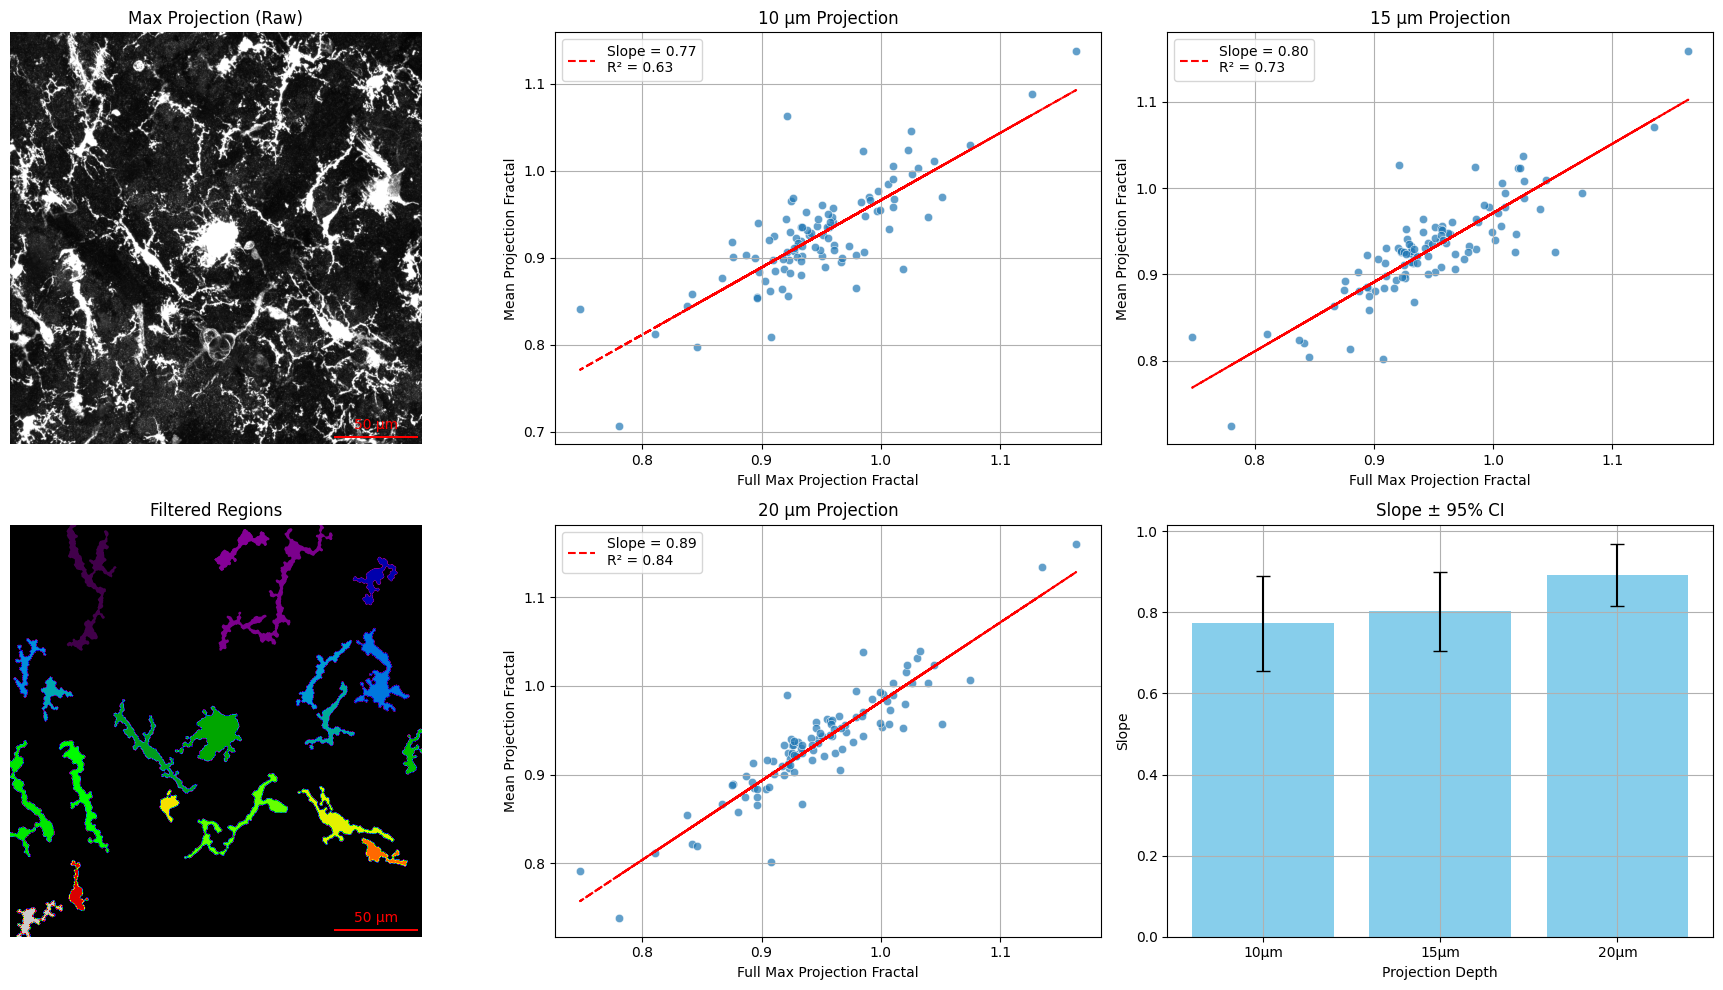

In [6]:
plot_image_and_scatter_grid_2x3(
    max_proj=max_proj,
    filtered_mask=filtered,
    df_list=[final_df_10, final_df_15, final_df_20],
    micron_depths=[10, 15, 20],
    pixel_size=4.158,
    save_pdf='ihc_outs/max_proj_qc_zoomed_scaled.pdf'
)